In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('assets', exist_ok=True)

print('All libraries loaded.')
print(f'   TensorFlow: {tf.__version__}')

I0000 00:00:1776495531.886245  175010 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776495531.973407  175010 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776495535.538396  175010 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✅ All libraries loaded.
   TensorFlow: 2.21.0


### Dataset Paths


In [3]:
# Correct absolute paths pointing 
CHEST_PATH = r'/home/ssh_users/EX2-main/chest_xray'
BRAIN_PATH = r'/home/ssh_users/EX2-main/brain_tumor'

# Verify paths exist
for p in [CHEST_PATH, BRAIN_PATH]:
    status = '✅' if os.path.exists(p) else '❌ NOT FOUND'
    print(f'{status}: {p}')

# Quick audit of what folders are inside
print('\nChest Train Classes:', os.listdir(os.path.join(CHEST_PATH, 'train')))
print('Brain Training Classes:', os.listdir(os.path.join(BRAIN_PATH, 'Training')))

✅: /home/ssh_users/EX2-main/chest_xray
✅: /home/ssh_users/EX2-main/brain_tumor

Chest Train Classes: ['.DS_Store', 'PNEUMONIA', 'NORMAL']
Brain Training Classes: ['meningioma_tumor', 'pituitary_tumor', 'glioma_tumor', 'no_tumor']


### Step 3: The Universal Data Loader

ONE flexible loader that handles:
- Both Chest (uppercase `NORMAL`, `PNEUMONIA`) and Brain (lowercase with `_tumor` suffix) folder names
- Both grayscale 150×150 (for PCA and Raw XGBoost) and RGB 224×224 (for VGG16)
- The explicit `train/test` split that already exists on disk 

In [ ]:
def load_images(base_path, split_folder, size, rgb=False, cap=500):
    """
    Load images from a split folder.
    
    Folder name to label mapping:
      Chest: NORMAL -> 0,  PNEUMONIA -> 1
      Brain: glioma_tumor -> 0,  meningioma_tumor -> 1,  pituitary_tumor -> 2,  no_tumor -> 3
    
    """
    X, y = [], []
    target_dir = os.path.join(base_path, split_folder)
    
    def get_label(folder_name):
        fn = folder_name.lower()
        # Chest classes
        if fn == 'normal': return 0
        if fn == 'pneumonia': return 1
        # Brain classes (partial match, tolerates _tumor suffix)
        if 'glioma' in fn: return 0
        if 'meningioma' in fn: return 1
        if 'pituitary' in fn: return 2
        if 'no_tumor' in fn or 'notumor' in fn: return 3
        return None  # unknown folder, skip
    
    print(f'Scanning: {target_dir}')
    for cls_folder in sorted(os.listdir(target_dir)):
        if cls_folder.startswith('.'): continue  # skip .DS_Store etc.
        label = get_label(cls_folder)
        if label is None: continue
        cls_path = os.path.join(target_dir, cls_folder)
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        count = 0
        for fname in files:
            if count >= cap: break
            img_path = os.path.join(cls_path, fname)
            img = cv2.imread(img_path)
            if img is None: continue
            if rgb:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, size)
                X.append(img)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = cv2.resize(img, size)
                X.append(img.flatten())
            y.append(label)
            count += 1
        print(f'  [{cls_folder}] -> Label {label}: loaded {count} images')
    print(f'  Total: {len(X)} images\n')
    return np.array(X), np.array(y)

print('✅ Data loader defined.')

✅ Data loader defined.


### Load All Datasets

load 4 dataset variants. The train/test split comes from the folder structure itself — **no data leakage**.

In [9]:
print('='*60)
print('CHEST X-RAY  (Binary: Normal=0, Pneumonia=1)')
print('='*60)
X_chest_train, y_chest_train = load_images(CHEST_PATH, 'train', size=(150, 150), rgb=False, cap=5000)
X_chest_test,  y_chest_test  = load_images(CHEST_PATH, 'test',  size=(150, 150), rgb=False, cap=5000)

print('='*60)
print('BRAIN TUMORS (4-class: Glioma=0, Meningioma=1, Pituitary=2, NoTumor=3)')
print('='*60)
X_brain_train, y_brain_train = load_images(BRAIN_PATH, 'Training', size=(150, 150), rgb=False, cap=5000)
X_brain_test,  y_brain_test  = load_images(BRAIN_PATH, 'Testing',  size=(150, 150), rgb=False, cap=5000)

print(f'Chest  Train: {X_chest_train.shape}, Test: {X_chest_test.shape}')
print(f'Brain  Train: {X_brain_train.shape}, Test: {X_brain_test.shape}')

CHEST X-RAY  (Binary: Normal=0, Pneumonia=1)
Scanning: /home/ssh_users/EX2-main/chest_xray/train
  [NORMAL] -> Label 0: loaded 1341 images
  [PNEUMONIA] -> Label 1: loaded 3875 images
  Total: 5216 images

Scanning: /home/ssh_users/EX2-main/chest_xray/test
  [NORMAL] -> Label 0: loaded 234 images
  [PNEUMONIA] -> Label 1: loaded 390 images
  Total: 624 images

BRAIN TUMORS (4-class: Glioma=0, Meningioma=1, Pituitary=2, NoTumor=3)
Scanning: /home/ssh_users/EX2-main/brain_tumor/Training
  [glioma_tumor] -> Label 0: loaded 826 images
  [meningioma_tumor] -> Label 1: loaded 822 images
  [no_tumor] -> Label 3: loaded 395 images
  [pituitary_tumor] -> Label 2: loaded 827 images
  Total: 2870 images

Scanning: /home/ssh_users/EX2-main/brain_tumor/Testing
  [glioma_tumor] -> Label 0: loaded 100 images
  [meningioma_tumor] -> Label 1: loaded 115 images
  [no_tumor] -> Label 3: loaded 105 images
  [pituitary_tumor] -> Label 2: loaded 74 images
  Total: 394 images

Chest  Train: (5216, 22500), Te

### Visualise Sample Images from Each Dataset


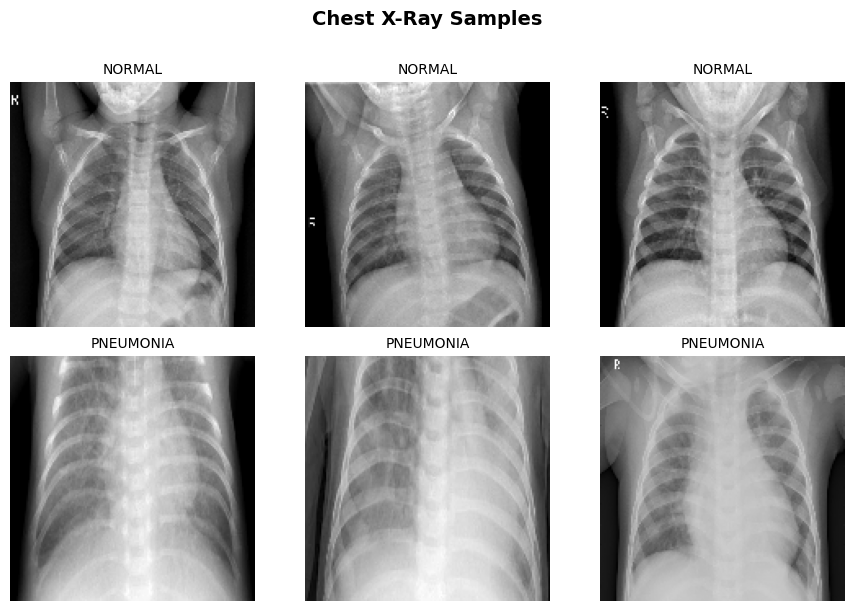

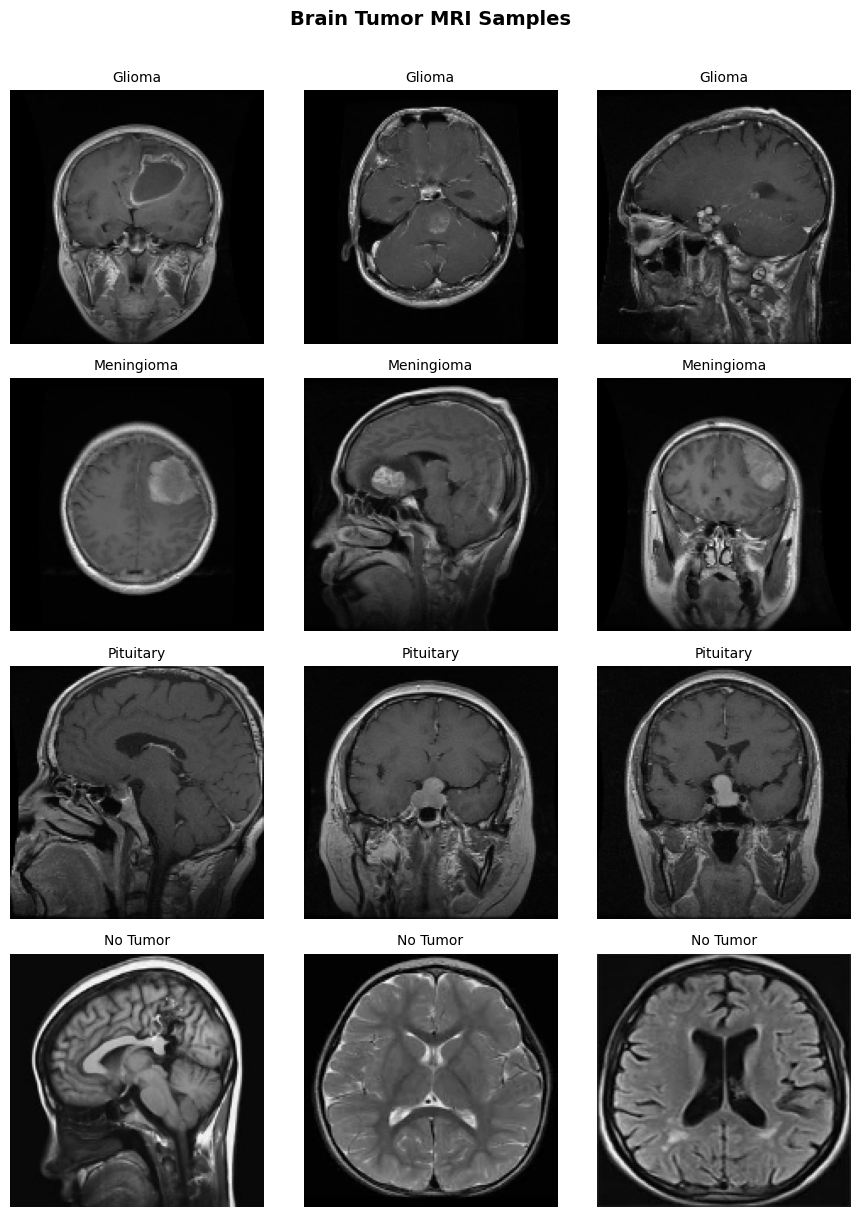

✅ Sample images displayed.


In [10]:
chest_class_names = {0: 'NORMAL', 1: 'PNEUMONIA'}
brain_class_names = {0: 'Glioma', 1: 'Meningioma', 2: 'Pituitary', 3: 'No Tumor'}

def show_samples(X, y, class_names, title, n_per_class=3):
    classes = sorted(class_names.keys())
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class*3, len(classes)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    for row, cls in enumerate(classes):
        idxs = np.where(y == cls)[0][:n_per_class]
        for col, idx in enumerate(idxs):
            ax = axes[row][col] if len(classes) > 1 else axes[col]
            img = X[idx].reshape(150, 150)
            ax.imshow(img, cmap='gray')
            ax.set_title(class_names[cls], fontsize=10)
            ax.axis('off')
    plt.tight_layout()
    return fig

fig1 = show_samples(X_chest_train, y_chest_train, chest_class_names, 'Chest X-Ray Samples')
plt.savefig('assets/chest_samples.png', bbox_inches='tight', dpi=150)
plt.show()

fig2 = show_samples(X_brain_train, y_brain_train, brain_class_names, 'Brain Tumor MRI Samples')
plt.savefig('assets/brain_samples.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Sample images displayed.')

### 4-Metric used,

- **Accuracy**
- **F1-Score**
- **Sensitivity (Recall)**
- **Specificity** 


In [11]:
def evaluate(y_true, y_pred, class_names, model_name='Model', dataset_name='Dataset', plot_cm=True):
    """Compute and display all 4 required metrics + confusion matrix."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted')
    cm  = confusion_matrix(y_true, y_pred)

    n_classes = len(cm)
    if n_classes == 2:
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        # Macro-average: compute per-class then average
        sensititivies, specificities = [], []
        for i in range(n_classes):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            sensititivies.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
            specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
        sensitivity = np.mean(sensititivies)
        specificity = np.mean(specificities)

    print(f'\n📊 {model_name} on {dataset_name}')
    print(f'   Accuracy    : {acc*100:.2f}%')
    print(f'   F1-Score    : {f1:.4f}')
    print(f'   Sensitivity : {sensitivity:.4f}')
    print(f'   Specificity : {specificity:.4f}')

    if plot_cm:
        labels = [class_names[i] for i in sorted(class_names.keys())]
        fig, ax = plt.subplots(figsize=(6, 5))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'Confusion Matrix — {model_name} ({dataset_name})')
        plt.tight_layout()
        fname = f'assets/cm_{model_name.replace(" ","_").replace("+","plus")}_{dataset_name.replace(" ","_")}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()

    return {'acc': acc, 'f1': f1, 'sens': sensitivity, 'spec': specificity}

print('✅ 4-metric evaluation helper ready.')

✅ 4-metric evaluation helper ready.


## 1: PCA + XGBoost



CHEST X-RAY: PCA + XGBoost
--- PCA(100) + XGBoost on Chest ---
  PCA: reduced 22500D -> 100D
  Explained variance: 86.2%

📊 PCA+XGB on Chest
   Accuracy    : 77.24%
   F1-Score    : 0.7442
   Sensitivity : 0.9872
   Specificity : 0.4145


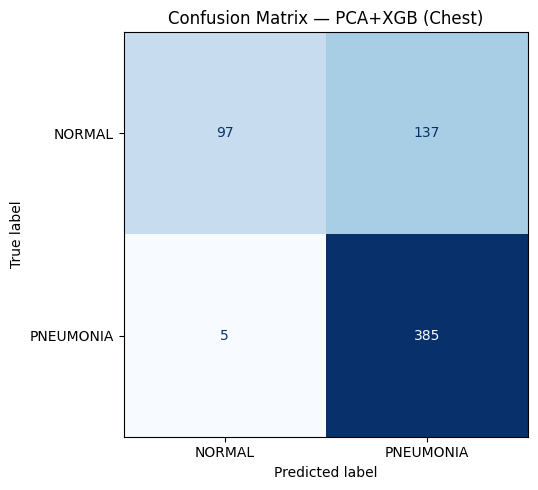


BRAIN TUMORS: PCA + XGBoost
--- PCA(100) + XGBoost on Brain ---
  PCA: reduced 22500D -> 100D
  Explained variance: 70.4%

📊 PCA+XGB on Brain
   Accuracy    : 76.65%
   F1-Score    : 0.7181
   Sensitivity : 0.7646
   Specificity : 0.9211


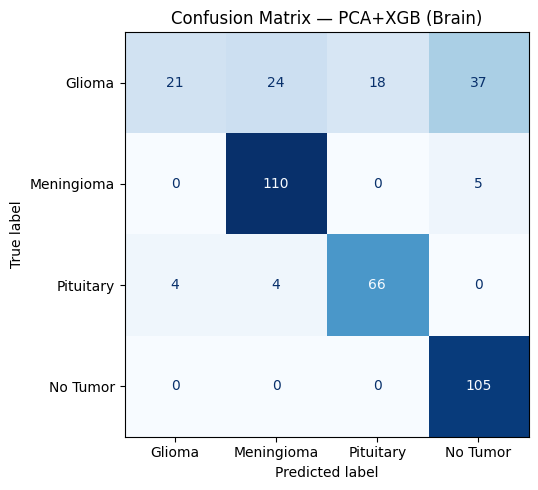

In [12]:
def run_pca_xgb(X_train, y_train, X_test, y_test, n_components, class_names, dataset_name):
    print(f'--- PCA({n_components}) + XGBoost on {dataset_name} ---')
    n_classes = len(np.unique(y_train))
    # PCA
    pca = PCA(n_components=n_components, random_state=42)
    X_tr = pca.fit_transform(X_train)
    X_te = pca.transform(X_test)
    print(f'  PCA: reduced {X_train.shape[1]}D -> {n_components}D')
    print(f'  Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')
    # XGBoost
    objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'
    xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                         objective=objective, num_class=n_classes if n_classes > 2 else None,
                         eval_metric='mlogloss', random_state=42, verbosity=0)
    xgb.fit(X_tr, y_train)
    preds = xgb.predict(X_te)
    metrics = evaluate(y_test, preds, class_names, 'PCA+XGB', dataset_name)
    return metrics, pca, xgb

print('\n' + '='*55)
print('CHEST X-RAY: PCA + XGBoost')
print('='*55)
chest_pca_metrics, _, _ = run_pca_xgb(X_chest_train, y_chest_train, X_chest_test, y_chest_test,
                                        n_components=100, class_names=chest_class_names, dataset_name='Chest')

print('\n' + '='*55)
print('BRAIN TUMORS: PCA + XGBoost')
print('='*55)
brain_pca_metrics, _, _ = run_pca_xgb(X_brain_train, y_brain_train, X_brain_test, y_brain_test,
                                        n_components=100, class_names=brain_class_names, dataset_name='Brain')

---
## 2: VGG16 + XGBoost


In [14]:
# Load RGB 224x224 for VGG16 — we cap at 300 to stay within laptop RAM
print('Loading RGB data for VGG16 feature extraction...')
print('\nChest Train (RGB):')
X_chest_train_rgb, y_chest_train_rgb = load_images(CHEST_PATH, 'train', size=(224, 224), rgb=True, cap=3000)
print('Chest Test (RGB):')
X_chest_test_rgb, y_chest_test_rgb   = load_images(CHEST_PATH, 'test',  size=(224, 224), rgb=True, cap=2340)
print('Brain Train (RGB):')
X_brain_train_rgb, y_brain_train_rgb = load_images(BRAIN_PATH, 'Training', size=(224, 224), rgb=True, cap=3000)
print('Brain Test (RGB):')
X_brain_test_rgb, y_brain_test_rgb   = load_images(BRAIN_PATH, 'Testing',  size=(224, 224), rgb=True, cap=3000)

print(f'Chest RGB Train: {X_chest_train_rgb.shape}, Test: {X_chest_test_rgb.shape}')
print(f'Brain RGB Train: {X_brain_train_rgb.shape}, Test: {X_brain_test_rgb.shape}')

Loading RGB data for VGG16 feature extraction...

Chest Train (RGB):
Scanning: /home/ssh_users/EX2-main/chest_xray/train
  [NORMAL] -> Label 0: loaded 1341 images
  [PNEUMONIA] -> Label 1: loaded 3000 images
  Total: 4341 images

Chest Test (RGB):
Scanning: /home/ssh_users/EX2-main/chest_xray/test
  [NORMAL] -> Label 0: loaded 234 images
  [PNEUMONIA] -> Label 1: loaded 390 images
  Total: 624 images

Brain Train (RGB):
Scanning: /home/ssh_users/EX2-main/brain_tumor/Training
  [glioma_tumor] -> Label 0: loaded 826 images
  [meningioma_tumor] -> Label 1: loaded 822 images
  [no_tumor] -> Label 3: loaded 395 images
  [pituitary_tumor] -> Label 2: loaded 827 images
  Total: 2870 images

Brain Test (RGB):
Scanning: /home/ssh_users/EX2-main/brain_tumor/Testing
  [glioma_tumor] -> Label 0: loaded 100 images
  [meningioma_tumor] -> Label 1: loaded 115 images
  [no_tumor] -> Label 3: loaded 105 images
  [pituitary_tumor] -> Label 2: loaded 74 images
  Total: 394 images

Chest RGB Train: (4341,

In [18]:
# Build VGG16 feature extractor (once, shared across both datasets)
print('Building VGG16 feature extractor...')
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg16_base.trainable = False
print(f'VGG16 output shape: {vgg16_base.output_shape}  →  flattened = {7*7*512} features')

def extract_vgg_features(images_array, batch_size=32):
    """Run VGG16 on a batch of RGB images and flatten the output."""
    # VGG16 preprocessing subtracts ImageNet mean — IMPORTANT for correct features
    processed = preprocess_input(images_array.astype('float32'))
    features = vgg16_base.predict(processed, batch_size=batch_size, verbose=1)
    return features.reshape(features.shape[0], -1)

print('\nExtracting features from Chest X-Ray...')
F_chest_train = extract_vgg_features(X_chest_train_rgb)
F_chest_test  = extract_vgg_features(X_chest_test_rgb)

print('\nExtracting features from Brain Tumors...')
F_brain_train = extract_vgg_features(X_brain_train_rgb)
F_brain_test  = extract_vgg_features(X_brain_test_rgb)

print(f'\nChest Feature Vectors: train={F_chest_train.shape}, test={F_chest_test.shape}')
print(f'Brain Feature Vectors: train={F_brain_train.shape}, test={F_brain_test.shape}')

Building VGG16 feature extractor...


E0000 00:00:1776497349.934170  175010 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1776497349.981100  175010 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1776497349.993234  175010 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1776497350.003341  175010 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776497350.109724  175010 gpu_device.cc:2365] Cannot

VGG16 output shape: (None, 7, 7, 512)  →  flattened = 25088 features

Extracting features from Chest X-Ray...


W0000 00:00:1776497374.879497  175010 cpu_allocator_impl.cc:82] Allocation of 2613768192 exceeds 10% of free system memory.
W0000 00:00:1776497378.405423  202615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1776497378.741341  202615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.


  1/136 ━━━━━━━━━━━━━━━━━━━━ 10:23 5s/step

W0000 00:00:1776497382.848514  202615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1776497382.986026  202615 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.


136/136 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step

Extracting features from Brain Tumors...
90/90 ━━━━━━━━━━━━━━━━━━━━ 313s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step

Chest Feature Vectors: train=(4341, 25088), test=(624, 25088)
Brain Feature Vectors: train=(2870, 25088), test=(394, 25088)



CHEST X-RAY: VGG16 + XGBoost
--- VGG16+XGBoost on Chest ---

📊 VGG16+XGB on Chest
   Accuracy    : 79.49%
   F1-Score    : 0.7732
   Sensitivity : 0.9897
   Specificity : 0.4701


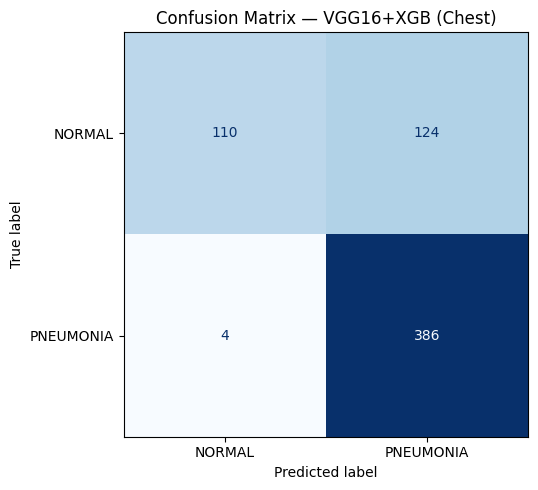


BRAIN TUMORS: VGG16 + XGBoost
--- VGG16+XGBoost on Brain ---

📊 VGG16+XGB on Brain
   Accuracy    : 78.93%
   F1-Score    : 0.7433
   Sensitivity : 0.7905
   Specificity : 0.9271


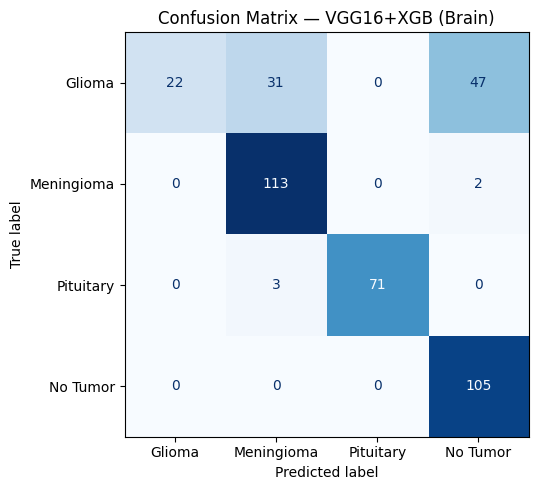

In [19]:
def run_vgg_xgb(F_train, y_train, F_test, y_test, class_names, dataset_name):
    print(f'--- VGG16+XGBoost on {dataset_name} ---')
    n_classes = len(np.unique(y_train))
    objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'
    xgb = XGBClassifier(n_estimators=120, learning_rate=0.1, max_depth=6,
                         objective=objective, num_class=n_classes if n_classes > 2 else None,
                         eval_metric='mlogloss', random_state=42, verbosity=0)
    xgb.fit(F_train, y_train)
    preds = xgb.predict(F_test)
    metrics = evaluate(y_test, preds, class_names, 'VGG16+XGB', dataset_name)
    return metrics


print('\n' + '='*55)
print('CHEST X-RAY: VGG16 + XGBoost')
print('='*55)
chest_vgg_metrics = run_vgg_xgb(F_chest_train, y_chest_train_rgb, F_chest_test, y_chest_test,
                                  class_names=chest_class_names, dataset_name='Chest')

print('\n' + '='*55)
print('BRAIN TUMORS: VGG16 + XGBoost')
print('='*55)
brain_vgg_metrics = run_vgg_xgb(F_brain_train, y_brain_train_rgb, F_brain_test, y_brain_test,
                                  class_names=brain_class_names, dataset_name='Brain')

---
## 3: Raw XGBoost (Baseline)



CHEST X-RAY: Raw XGBoost
--- Raw XGBoost on Chest (input dim=22500) ---

📊 Raw XGB on Chest
   Accuracy    : 74.52%
   F1-Score    : 0.7061
   Sensitivity : 0.9872
   Specificity : 0.3419


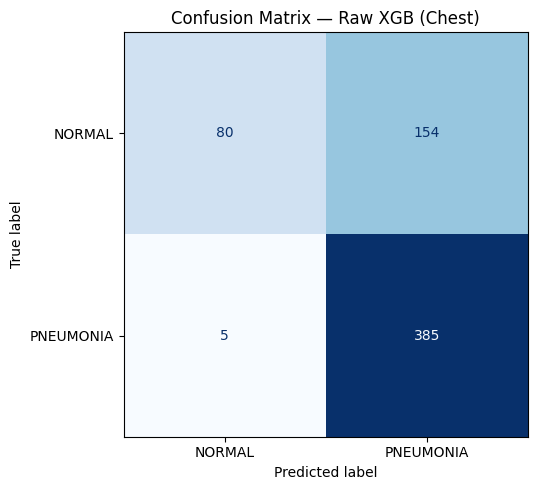


BRAIN TUMORS: Raw XGBoost
--- Raw XGBoost on Brain (input dim=22500) ---

📊 Raw XGB on Brain
   Accuracy    : 71.07%
   F1-Score    : 0.6658
   Sensitivity : 0.6917
   Specificity : 0.9014


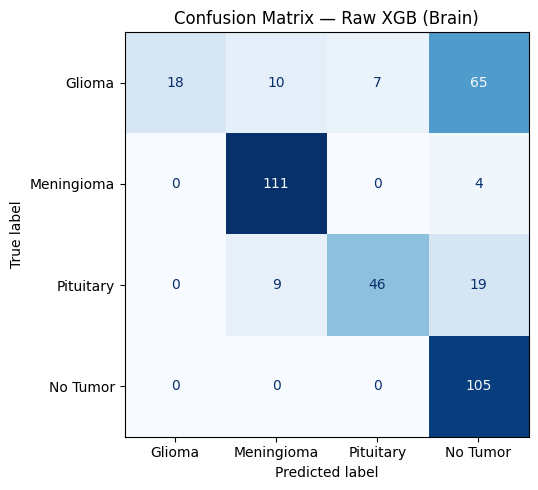

In [20]:
def run_raw_xgb(X_train, y_train, X_test, y_test, class_names, dataset_name):
    print(f'--- Raw XGBoost on {dataset_name} (input dim={X_train.shape[1]}) ---')
    n_classes = len(np.unique(y_train))
    objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'
    xgb = XGBClassifier(n_estimators=120, learning_rate=0.1, max_depth=6,
                         objective=objective, num_class=n_classes if n_classes > 2 else None,
                         eval_metric='mlogloss', random_state=42, verbosity=0,
                         subsample=0.8, colsample_bytree=0.3)  # subsample needed for 22500-dim input
    xgb.fit(X_train, y_train)
    preds = xgb.predict(X_test)
    metrics = evaluate(y_test, preds, class_names, 'Raw XGB', dataset_name)
    return metrics

print('\n' + '='*55)
print('CHEST X-RAY: Raw XGBoost')
print('='*55)
chest_raw_metrics = run_raw_xgb(X_chest_train, y_chest_train, X_chest_test, y_chest_test,
                                  class_names=chest_class_names, dataset_name='Chest')

print('\n' + '='*55)
print('BRAIN TUMORS: Raw XGBoost')
print('='*55)
brain_raw_metrics = run_raw_xgb(X_brain_train, y_brain_train, X_brain_test, y_brain_test,
                                  class_names=brain_class_names, dataset_name='Brain')

---
## 4: Data Starvation
**20%, 40%, 60%, 80%, 100%**

In [21]:
def starvation_study(X_train_gray, y_train_sub,
                     X_test_gray,  y_test,
                     F_train_vgg,  F_test_vgg,
                     n_classes, dataset_name):
    portions = [0.20, 0.40, 0.60, 0.80, 1.00]
    pct_labels = [f'{int(p*100)}%' for p in portions]
    results = {m: [] for m in ['PCA+XGB', 'VGG16+XGB', 'Raw+XGB']}
    objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'

    for p in portions:
        if p < 1.0:
            idx = np.random.choice(len(X_train_gray), int(len(X_train_gray)*p), replace=False)
        else:
            idx = np.arange(len(X_train_gray))
        X_r, y_r = X_train_gray[idx], y_train_sub[idx]
        # VGG: indices capped at F_train_vgg length
        vgg_idx = idx[idx < len(F_train_vgg)]
        F_v, y_v = F_train_vgg[vgg_idx], y_train_sub[vgg_idx]
        print(f'  {int(p*100)}% — Raw:{len(X_r)}, VGG:{len(F_v)}')

        # PCA + XGB
        n_comp = min(100, len(X_r)-1)
        pca = PCA(n_components=n_comp, random_state=42)
        m1 = XGBClassifier(n_estimators=80, learning_rate=0.1, max_depth=5,
                             objective=objective, num_class=n_classes if n_classes > 2 else None,
                             eval_metric='mlogloss', random_state=42, verbosity=0)
        m1.fit(pca.fit_transform(X_r), y_r)
        results['PCA+XGB'].append(accuracy_score(y_test, m1.predict(pca.transform(X_test_gray))))

        # VGG + XGB
        m2 = XGBClassifier(n_estimators=80, learning_rate=0.1, max_depth=6,
                             objective=objective, num_class=n_classes if n_classes > 2 else None,
                             eval_metric='mlogloss', random_state=42, verbosity=0)
        m2.fit(F_v, y_v)
        results['VGG16+XGB'].append(accuracy_score(y_test, m2.predict(F_test_vgg)))

        # Raw XGB
        m3 = XGBClassifier(n_estimators=80, learning_rate=0.1, max_depth=6,
                             objective=objective, num_class=n_classes if n_classes > 2 else None,
                             eval_metric='mlogloss', random_state=42, verbosity=0,
                             subsample=0.8, colsample_bytree=0.3)
        m3.fit(X_r, y_r)
        results['Raw+XGB'].append(accuracy_score(y_test, m3.predict(X_test_gray)))

    return pct_labels, results

print('\n' + '='*55)
print('CHEST X-RAY STARVATION STUDY')
print('='*55)
chest_labels, chest_starvation = starvation_study(
    X_chest_train, y_chest_train, X_chest_test, y_chest_test,
    F_chest_train, F_chest_test, n_classes=2, dataset_name='Chest')

print('\n' + '='*55)
print('BRAIN TUMOR STARVATION STUDY')
print('='*55)
brain_labels, brain_starvation = starvation_study(
    X_brain_train, y_brain_train, X_brain_test, y_brain_test,
    F_brain_train, F_brain_test, n_classes=4, dataset_name='Brain')


CHEST X-RAY STARVATION STUDY
  20% — Raw:1043, VGG:854
  40% — Raw:2086, VGG:1750
  60% — Raw:3129, VGG:2596
  80% — Raw:4172, VGG:3472
  100% — Raw:5216, VGG:4341

BRAIN TUMOR STARVATION STUDY
  20% — Raw:574, VGG:574
  40% — Raw:1148, VGG:1148
  60% — Raw:1722, VGG:1722
  80% — Raw:2296, VGG:2296
  100% — Raw:2870, VGG:2870


### Plot the Starvation Results


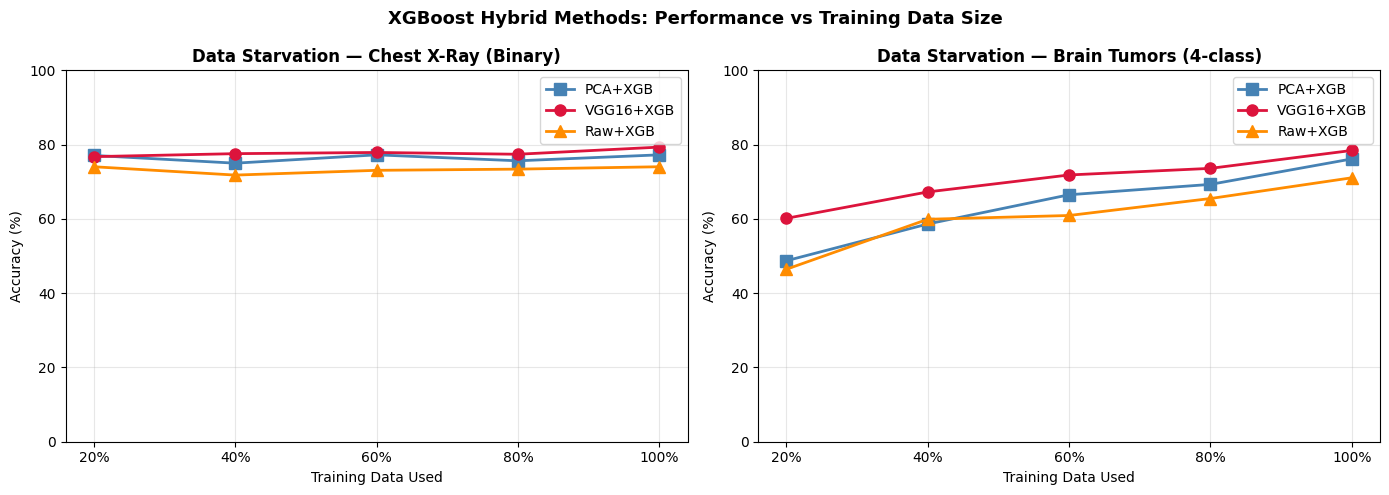

✅ Starvation plot saved to assets/.


In [22]:
colors = {'PCA+XGB': 'steelblue', 'VGG16+XGB': 'crimson', 'Raw+XGB': 'darkorange'}
markers = {'PCA+XGB': 's', 'VGG16+XGB': 'o', 'Raw+XGB': '^'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, results, title in [
    (axes[0], chest_labels, chest_starvation, 'Chest X-Ray (Binary)'),
    (axes[1], brain_labels, brain_starvation,  'Brain Tumors (4-class)')
]:
    for method, accs in results.items():
        ax.plot(labels, [a*100 for a in accs], marker=markers[method],
                color=colors[method], label=method, linewidth=2, markersize=8)
    ax.set_title(f'Data Starvation — {title}', fontweight='bold')
    ax.set_xlabel('Training Data Used')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

plt.suptitle('XGBoost Hybrid Methods: Performance vs Training Data Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/xgboost_starvation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Starvation plot saved to assets/.')

---
## Summary: All 4 Metrics Across All Experiments

In [25]:
import pandas as pd

def make_summary_table(pca_m, vgg_m, raw_m, dataset):
    rows = []
    for model_name, m in [('PCA + XGBoost', pca_m), ('VGG16 + XGBoost', vgg_m), ('Raw XGBoost', raw_m)]:
        rows.append({
            'Dataset': dataset,
            'Model': model_name,
            'Accuracy (%)': f"{m['acc']*100:.2f}",
            'F1-Score': f"{m['f1']:.4f}",
            'Sensitivity': f"{m['sens']:.4f}",
            'Specificity': f"{m['spec']:.4f}",
        })
    return pd.DataFrame(rows)

df_chest = make_summary_table(chest_pca_metrics, chest_vgg_metrics, chest_raw_metrics, 'Chest X-Ray')
df_brain = make_summary_table(brain_pca_metrics, brain_vgg_metrics, brain_raw_metrics, 'Brain Tumor')

df_all = pd.concat([df_chest, df_brain], ignore_index=True)

print('\n========== COMPLETE RESULTS SUMMARY ==========')
print(df_all.to_string(index=False))


========== COMPLETE RESULTS SUMMARY ==========
    Dataset           Model Accuracy (%) F1-Score Sensitivity Specificity
Chest X-Ray   PCA + XGBoost        77.24   0.7442      0.9872      0.4145
Chest X-Ray VGG16 + XGBoost        79.49   0.7732      0.9897      0.4701
Chest X-Ray     Raw XGBoost        74.52   0.7061      0.9872      0.3419
Brain Tumor   PCA + XGBoost        76.65   0.7181      0.7646      0.9211
Brain Tumor VGG16 + XGBoost        78.93   0.7433      0.7905      0.9271
Brain Tumor     Raw XGBoost        71.07   0.6658      0.6917      0.9014


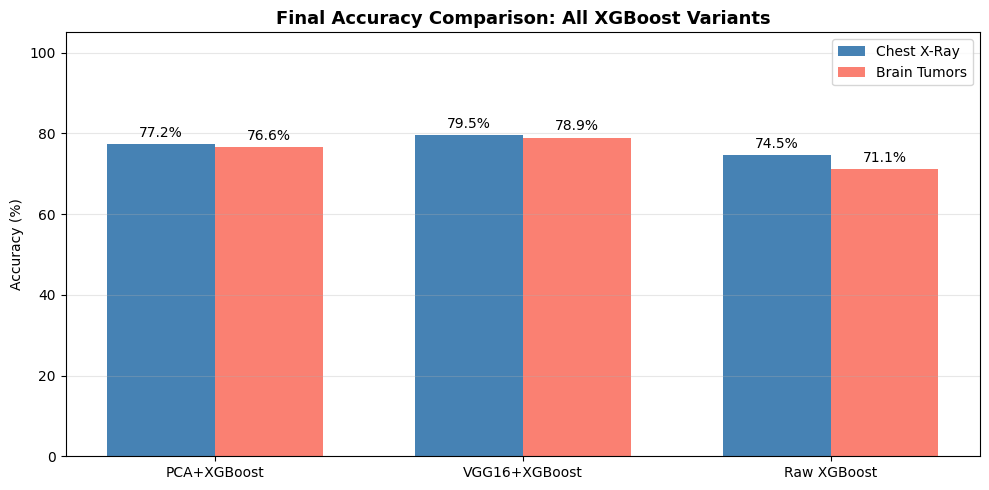

✅ Final comparison chart saved.


In [26]:
# Visual grouped bar chart: Accuracy across all models and datasets
models = ['PCA+XGBoost', 'VGG16+XGBoost', 'Raw XGBoost']

chest_accs = [chest_pca_metrics['acc']*100, chest_vgg_metrics['acc']*100, chest_raw_metrics['acc']*100]
brain_accs  = [brain_pca_metrics['acc']*100, brain_vgg_metrics['acc']*100, brain_raw_metrics['acc']*100]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, chest_accs, width, label='Chest X-Ray', color='steelblue')
b2 = ax.bar(x + width/2, brain_accs,  width, label='Brain Tumors', color='salmon')

ax.bar_label(b1, fmt='%.1f%%', padding=3)
ax.bar_label(b2, fmt='%.1f%%', padding=3)

ax.set_title('Final Accuracy Comparison: All XGBoost Variants', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('assets/final_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Final comparison chart saved.')

---
## Conclusions


| Observation | Explanation |
| :--- | :--- |
| **VGG16+XGB drops least with less data** | Pre-trained features are already rich. XGBoost needs fewer examples to generalize. |
| **Raw XGBoost degrades fastest** | 22,500 raw pixel features are noisy. With less data, XGBoost overfits immediately. |
| **PCA+XGB sits in between** | PCA filtering removes noise but loses biological context. |

### Connection Across Three Exercises

```
EX1 (PCA + SVM)       →  EX3 (PCA + XGBoost)   : Same pipeline, stronger classifier
EX2 (Transfer CNN)    →  EX3 (VGG16 + XGBoost)  : Feature extractor + external classifier
EX3 (Raw XGBoost)     : The floor — raw pixels, no preprocessing
```

**VGG16 + XGBoost is the recommended architecture** when you have limited medical data and need the highest accuracy ceiling. It inherits millions of parameters of visual knowledge from ImageNet and refines it with domain-specific boosting.